# Actividad: Volatility Skew — SPY

Edgardo González

**Objetivo:** Calcular la volatilidad implícita para al menos 10 strikes distintos del vencimiento `2026-04-17` en el rango `[S0 × 0.88, S0 × 1.10]`, construir una tabla de resultados y graficar el *volatility skew*.

**Activo:** SPY  
**Vencimiento:** 2026-04-17  
**Tipo de opción:** Call  
**Tasa libre de riesgo:** 4.2% (tasa aproximada del Treasury a corto plazo)

In [1]:
# ─────────────────────────────────────────────
# CELDA 1: Importaciones y funciones base
# Se reutilizan las funciones del código visto en clase:
#   - bs_price: precio teórico de Black-Scholes
#   - bs_vega:  derivada del precio respecto a sigma (usada en Newton)
#   - implied_vol: encuentra IV combinando Brent + Newton
# ─────────────────────────────────────────────

import numpy as np
import pandas as pd
import yfinance as yf
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, newton
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')


# ── Black-Scholes: precio teórico ──────────────────────────────────────────
def bs_price(S, K, r, T, sigma, option="call"):
    """Devuelve el precio Black-Scholes de una call o put europea."""
    if sigma <= 0 or T <= 0:
        if option == "call":
            return max(0.0, S - K * np.exp(-r * T))
        else:
            return max(0.0, K * np.exp(-r * T) - S)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option.lower() == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


# ── Black-Scholes: vega (derivada respecto a sigma) ────────────────────────
def bs_vega(S, K, r, T, sigma):
    """Calcula la vega de la opción. Se usa como derivada en el método de Newton."""
    if sigma <= 0 or T <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


# ── Volatilidad implícita: Brent con fallback a Newton ─────────────────────
def implied_vol(price_mkt, S, K, r, T, option="call",
                brent_bounds=(1e-6, 5.0), tol=1e-8, maxiter=100, seed=0.2):
    """
    Calcula la volatilidad implícita dada una prima de mercado.
    Estrategia:
      1. Verifica que el precio esté dentro de los límites teóricos de no arbitraje.
      2. Intenta el método de Brent (robusto, no requiere derivada).
      3. Si Brent falla, usa Newton-Raphson con vega como derivada.
    """
    if option == "call":
        lower = max(0.0, S - K * np.exp(-r * T))
        upper = S
    else:
        lower = max(0.0, K * np.exp(-r * T) - S)
        upper = K * np.exp(-r * T)

    if not (lower - 1e-12 <= price_mkt <= upper + 1e-12):
        raise ValueError(f"Precio fuera de rango teórico [{lower:.4f}, {upper:.4f}]")

    def f(sig):
        return bs_price(S, K, r, T, sig, option) - price_mkt

    a, b = brent_bounds
    fa, fb = f(a), f(b)

    if fa * fb > 0:
        for b_try in [10.0, 15.0, 25.0, 50.0]:
            fb = f(b_try)
            if fa * fb <= 0:
                b = b_try
                break

    try:
        iv = brentq(f, a, b, xtol=tol, maxiter=maxiter)
        return iv
    except Exception:
        pass

    try:
        iv = newton(lambda s: f(s), seed,
                    fprime=lambda s: bs_vega(S, K, r, T, s),
                    tol=tol, maxiter=maxiter)
        if iv > 0:
            return iv
    except Exception:
        pass

    raise RuntimeError("No se pudo encontrar la volatilidad implícita.")


print("✓ Funciones cargadas correctamente.")

✓ Funciones cargadas correctamente.


In [2]:
# ─────────────────────────────────────────────
# CELDA 2: Parámetros del mercado
# Precio spot y tiempo al vencimiento obtenidos dinámicamente.
# ─────────────────────────────────────────────

TICKER = 'SPY'
EXP    = '2026-04-17'
r      = 0.042
today  = date.today()

# Precio spot dinámico
tk   = yf.Ticker(TICKER)
data = yf.download(TICKER, start='2023-01-01', end=today, progress=False)['Close']
S0   = float(data.iloc[-1])

# Tiempo al vencimiento en años
T = (date.fromisoformat(EXP) - today).days / 365

print(f"Activo   : {TICKER}")
print(f"S0       : {S0:.2f}")
print(f"Exp      : {EXP}")
print(f"T (años) : {T:.4f}  ({round(T*365)} días)")
print(f"r        : {r:.1%}")

Activo   : SPY
S0       : 670.79
Exp      : 2026-04-17
T (años) : 0.0822  (30 días)
r        : 4.2%


In [3]:
# ─────────────────────────────────────────────
# CELDA 3: Selección de strikes y cálculo de IV
#
# Filtra strikes en [S0×0.88, S0×1.10] con liquidez mínima,
# calcula mid = (bid + ask) / 2 y obtiene la IV de cada uno.
# ─────────────────────────────────────────────

K_min = S0 * 0.88
K_max = S0 * 1.10

calls = tk.option_chain(EXP).calls.copy()

# Filtro de rango y liquidez mínima
calls = calls[
    (calls['strike'] >= K_min) &
    (calls['strike'] <= K_max) &
    (calls['bid'] > 0) &
    (calls['ask'] > 0)
].copy()

# Precio mid dinámico
calls['mid'] = (calls['bid'] + calls['ask']) / 2

records = []

for _, row in calls.iterrows():
    K   = row['strike']
    mid = row['mid']
    try:
        iv = implied_vol(mid, S0, K, r, T, option="call")
        if 0.01 <= iv <= 2.0:
            records.append({
                'Strike': K,
                'Bid'   : round(row['bid'], 4),
                'Ask'   : round(row['ask'], 4),
                'Mid'   : round(mid, 4),
                'IV (%)'  : round(iv * 100, 2)
            })
    except Exception:
        pass

df_skew = pd.DataFrame(records).reset_index(drop=True)

print(f"Strikes calculados: {len(df_skew)}")
print(f"Rango de strikes  : [{df_skew['Strike'].min():.1f}, {df_skew['Strike'].max():.1f}]")

Strikes calculados: 88
Rango de strikes  : [650.0, 737.0]


In [4]:
# ─────────────────────────────────────────────
# CELDA 4: Tabla de resultados
# Strike | Bid | Ask | Mid | IV (%)
# ─────────────────────────────────────────────

print(f"\n{'='*52}")
print(f"  Volatility Skew — {TICKER}  |  Vencimiento: {EXP}")
print(f"  S0 = {S0:.2f}  |  r = {r:.1%}  |  T = {T:.4f} años")
print(f"{'='*52}\n")

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)

display(df_skew.style
        .format({'Strike': '{:.1f}', 'Bid': '{:.4f}',
                 'Ask': '{:.4f}', 'Mid': '{:.4f}', 'IV (%)': '{:.2f}'})
        .highlight_min(subset=['IV (%)'], color='#d4edda')
        .highlight_max(subset=['IV (%)'], color='#f8d7da')
        .set_caption(f"Tabla 1. Volatilidad implícita por strike — Calls {TICKER} ({EXP})"))


  Volatility Skew — SPY  |  Vencimiento: 2026-04-17
  S0 = 670.79  |  r = 4.2%  |  T = 0.0822 años



,Strike,Bid,Ask,Mid,IV (%)
0,650.0,23.0500,23.2800,23.1650,6.42
1,651.0,21.1100,23.9200,22.5150,7.97
2,652.0,20.4500,23.2100,21.8300,8.72
3,653.0,20.7100,21.2600,20.9850,8.84
4,654.0,19.4100,21.4600,20.4350,9.61
5,655.0,19.6400,19.8600,19.7500,9.94
6,656.0,18.9200,20.1300,19.5250,11.07
7,657.0,17.4300,19.5300,18.4800,10.59
8,658.0,17.7100,17.7700,17.7400,10.64
9,659.0,17.0700,17.1300,17.1000,10.84


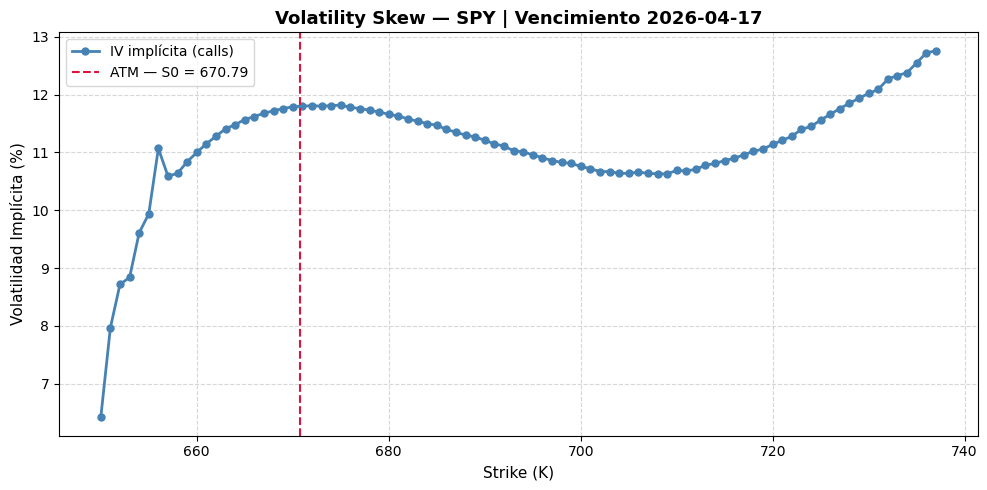

In [5]:
# ─────────────────────────────────────────────
# CELDA 5: Gráfica del Volatility Skew (2D)
#
# IV (%) vs Strike con línea vertical en S0.
# ─────────────────────────────────────────────

strikes = df_skew['Strike'].values
ivs     = df_skew['IV (%)'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(strikes, ivs, marker='o', linewidth=2,
        color='steelblue', markersize=5, label='IV implícita (calls)')

ax.axvline(x=S0, color='crimson', linestyle='--', linewidth=1.5,
           label=f'ATM — S0 = {S0:.2f}')

ax.set_title(f'Volatility Skew — {TICKER} | Vencimiento {EXP}', fontsize=13, fontweight='bold')
ax.set_xlabel('Strike (K)', fontsize=11)
ax.set_ylabel('Volatilidad Implícita (%)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Respuestas

### ¿La curva es decreciente, creciente o tiene forma de smile? ¿Qué implica?

La curva tiene forma de **smile asimétrico**. La IV baja desde ATM hacia el OTM moderado (alrededor de K = 708), y luego vuelve a subir hacia strikes más altos. Del lado izquierdo (ITM) también sube, aunque los primeros strikes muestran IVs raras por iliquidez.

Lo que implica es simple: el mercado no cree que todos los strikes tengan el mismo riesgo. Le asigna más incertidumbre a los extremos que al centro, y eso se refleja en precios más caros en esas zonas.

---

### ¿En qué strike es mínima la IV? ¿Coincide con S0?

El mínimo está en **K = 708–709 con 10.63%**, que es un 5.5% arriba del precio actual (S0 = 670.79). **No coincide con ATM.**

Cerca del precio spot la IV anda en 11.80%, bastante por encima del mínimo. Eso sugiere que el mercado está pagando más por opciones ATM de lo que BS esperaría, probablemente porque hay mucha demanda de calls y puts justo alrededor del precio actual.

---

### ¿Qué estarían comprando los inversores que pagan IV alta en strikes bajos?

Básicamente **cobertura contra caídas**. Una call muy ITM se comporta casi igual que tener el activo, y por paridad put-call, un strike bajo ITM en calls equivale a un strike bajo OTM en puts. Las puts OTM son el instrumento clásico de protección bajista — si esos strikes tienen IV alta, es porque hay gente dispuesta a pagar extra por cubrirse ante un crash del SPY.

En resumen: el ala izquierda del skew es el **precio del miedo**.

---

### ¿Qué le diría esta curva a alguien que quiere usar BS con sigma constante?

Que va a estar mal en casi todos los strikes. BS asume una sola σ para todo, pero aquí hay casi **6 puntos de diferencia** entre el mínimo (10.63%) y los extremos (hasta 12.76%). Si eliges una σ fija vas a subpreciar las opciones en los extremos y sobrepreciar las del medio, o al revés dependiendo de qué σ uses.

La realidad es que no existe *una* volatilidad del SPY: existe una superficie entera que varía por strike y por vencimiento. BS sigue siendo útil como lenguaje común para cotizar opciones, pero nadie lo usa con sigma constante en la práctica.

---
## Extra: Volatility Surface 3D

La gráfica anterior muestra el skew para un solo vencimiento. Si se calculan las IVs para todos los vencimientos disponibles, se obtiene la superficie de volatilidad completa, la misma que se vio en clase.

Puntos válidos: 546


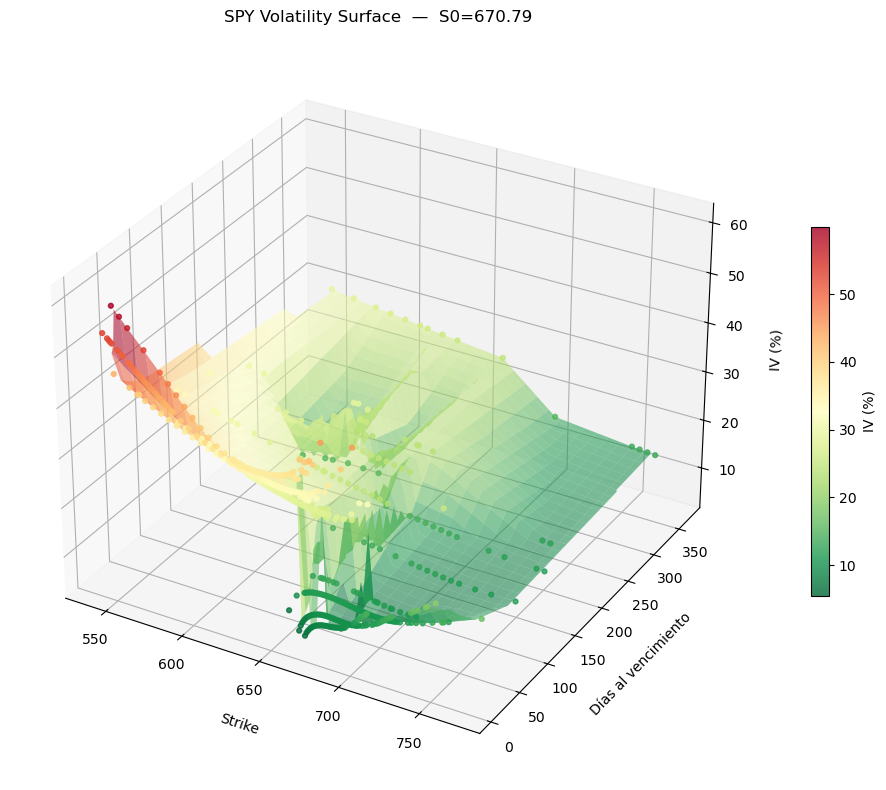

In [6]:
# ─────────────────────────────────────────────
# CELDA EXTRA: Volatility Surface 3D
#
# Replica la gráfica del código visto en clase:
# calcula IV para calls y puts de múltiples vencimientos
# y grafica la superficie Strike × Días × IV en 3D.
# ─────────────────────────────────────────────

# Selecciona hasta 8 vencimientos entre 7 y 400 días
all_exps = [(e, (date.fromisoformat(e) - today).days)
            for e in tk.options
            if 7 <= (date.fromisoformat(e) - today).days <= 400]

idx  = np.linspace(0, len(all_exps) - 1, min(8, len(all_exps)), dtype=int)
exps = [all_exps[i][0] for i in idx]

records_surf = []

for exp in exps:
    T_exp = (date.fromisoformat(exp) - today).days / 365

    calls_s = tk.option_chain(exp).calls.copy()
    puts_s  = tk.option_chain(exp).puts.copy()

    for df, opt_type in [(calls_s, "call"), (puts_s, "put")]:
        # Filtros de liquidez
        df = df[
            (df['bid'] > 0) &
            (df['ask'] > 0) &
            (df['volume'].fillna(0) > 50) &
            (df['ask'] / df['bid'] < 3.0) &
            (df['strike'] >= S0 * 0.80) &
            (df['strike'] <= S0 * 1.15)
        ].copy()
        df['mid'] = (df['bid'] + df['ask']) / 2

        for _, row in df.iterrows():
            K_s = row['strike']
            mid = row['mid']
            try:
                iv = implied_vol(mid, S0, K_s, r, T_exp, option=opt_type)
                if 0.05 <= iv <= 2.0:
                    records_surf.append({
                        'expiry': exp,
                        'days'  : round(T_exp * 365),
                        'K'     : K_s,
                        'type'  : opt_type,
                        'IV'    : iv * 100
                    })
            except Exception:
                pass

df_surf = pd.DataFrame(records_surf)
print(f"Puntos válidos: {len(df_surf)}")

# ── Gráfica 3D ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_surf['K'],
    df_surf['days'],
    df_surf['IV'],
    c=df_surf['IV'],
    cmap='RdYlGn_r',
    s=12,
    alpha=0.8
)

# Superficie interpolada encima de los puntos
ki = np.linspace(df_surf['K'].min(),    df_surf['K'].max(),    60)
ti = np.linspace(df_surf['days'].min(), df_surf['days'].max(), 60)
KK, TT = np.meshgrid(ki, ti)
IV_grid = griddata(
    (df_surf['K'], df_surf['days']),
    df_surf['IV'],
    (KK, TT),
    method='linear'
)

ax.plot_surface(KK, TT, IV_grid, cmap='RdYlGn_r', alpha=0.55, linewidth=0)

ax.set_xlabel('Strike',              labelpad=10)
ax.set_ylabel('Días al vencimiento', labelpad=10)
ax.set_zlabel('IV (%)',              labelpad=10)
ax.set_title(f'{TICKER} Volatility Surface  —  S0={S0:.2f}', pad=15)

fig.colorbar(scatter, ax=ax, shrink=0.5, label='IV (%)')
plt.tight_layout()
plt.show()